# Customer Churn Prediction - Data Preprocessing

This notebook prepares the raw data for machine learning models.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

## Load Raw Data

Import the synthetic customer churn dataset and inspect its structure.

In [2]:
# Path to local CSV
data_path = os.path.join("..", "data", "synthetic_customer_churn_100k.csv")
# Load dataset
df = pd.read_csv(data_path)

In [3]:
# Check data
print(df.shape)
print(df.head())
print(df.dtypes)

(100000, 9)
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0           1   56  Female      68          147.58        Two year   
1           2   69    Male      32           22.54  Month-to-month   
2           3   46  Female      10           52.47        One year   
3           4   32    Male      22          109.67  Month-to-month   
4           5   60  Female      54          130.98  Month-to-month   

      PaymentMethod  TotalCharges Churn  
0     Bank transfer      10052.03    No  
1      Mailed check        686.78    No  
2  Electronic check        537.88    No  
3      Mailed check       2390.04   Yes  
4       Credit card       7081.28    No  
CustomerID          int64
Age                 int64
Gender                str
Tenure              int64
MonthlyCharges    float64
Contract              str
PaymentMethod         str
TotalCharges      float64
Churn                 str
dtype: object


## Data Cleaning

Remove CustomerID (unique identifier with no predictive value).

In [4]:
# Drop CustomerID
df = df.drop('CustomerID', axis=1)

## Categorical Encoding

Encode categorical variables for machine learning:

| Column | Encoding | Values |
|--------|----------|--------|
| Gender | Binary | Female=0, Male=1 |
| Contract | Ordinal | Month-to-month=0, One year=1, Two year=2 |
| PaymentMethod | Label | Electronic check=0, Mailed check=1, etc. |
| Churn | Binary | No=0, Yes=1 |

**Note**: Contract uses ordinal encoding to preserve commitment length relationship.

In [5]:
# Define columns
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1})
df["Contract"] = df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

df["PaymentMethod"] = pd.factorize(df["PaymentMethod"])[0]

df.head()

,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,56,0.0,68,147.58,2,0,10052.03,0
1,69,1.0,32,22.54,0,1,686.78,0
2,46,0.0,10,52.47,1,2,537.88,0
3,32,1.0,22,109.67,0,1,2390.04,1
4,60,0.0,54,130.98,0,3,7081.28,0


## Target Distribution

Visualize class balance to identify potential imbalance issues.

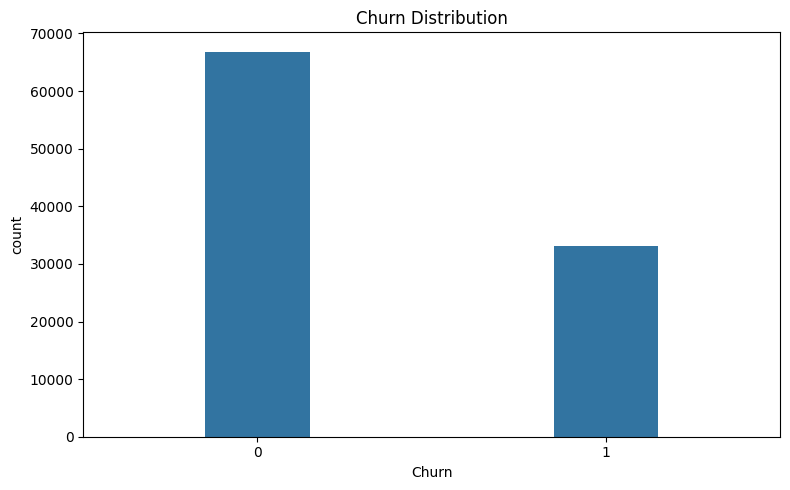

In [6]:
# Visualize churn distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Churn", width=0.3)
plt.title('Churn Distribution')
plt.tight_layout()
plt.show()

## Train-Test Split

Split data with stratification to maintain class distribution.

In [7]:
# Split features and target
x = df.drop("Churn", axis=1)
y = df["Churn"]
# Train-test split (30% test)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Churn rate in train: {y_train.mean():.4f}")

Train: (70000, 7), Test: (30000, 7)
Churn rate in train: 0.3301


## Feature Scaling

Apply StandardScaler to ensure all features contribute equally to model training.

In [8]:
# Cell 7: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

# Convert back to DataFrame for column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=x.columns, index=x_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=x.columns, index=x_test.index)

print("\nScaling complete")
print("Train mean (should be ~0):", X_train_scaled.mean().round(2).tolist())
print("Train std (should be ~1):", X_train_scaled.std().round(2).tolist())


Scaling complete
Train mean (should be ~0): [-0.0, 0.0, 0.0, -0.0, 0.0, 0.0, 0.0]
Train std (should be ~1): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Save Processed Data

Persist all artifacts for downstream model training.

In [ ]:
# Save data
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

joblib.dump(X_train_scaled, '../data/processed/X_train_scaled.pkl')
joblib.dump(X_test_scaled, '../data/processed/X_test_scaled.pkl')
joblib.dump(x_train, '../data/processed/x_train.pkl') # Unscaled
joblib.dump(x_test, '../data/processed/x_test.pkl') # Unscaled
joblib.dump(y_train, '../data/processed/y_train.pkl')
joblib.dump(y_test, '../data/processed/y_test.pkl')
joblib.dump(x.columns.tolist(), '../data/processed/feature_names.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Preprocessing complete")

Preprocessing complete
